In a classification tree, the dataset splits according to its variables. In this scenario, you have two variables, age and home, determining whether someone buys a house. If training data tells us that 70 percent of people over age 30 bought a house, then the data gets split there, with age becoming the first node in the tree. This split makes the data 80 percent "pure". The second node them addresses income from there.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [3]:
data = {
    'Age': [22, 25, 28, 30, 32, 35, 38, 40, 42, 45, 48, 50],
    'Income': [25, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90],
    'Buys_House': ['No', 'No', 'No', 'No', 'Yes', 'Yes',
                   'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes']
}
df = pd.DataFrame(data)
df

,Age,Income,Buys_House
0,22,25,No
1,25,35,No
2,28,40,No
3,30,45,No
4,32,50,Yes
5,35,55,Yes
6,38,60,Yes
7,40,65,Yes
8,42,70,Yes
9,45,75,Yes


In [4]:
#separate input & ouput

X = df[['Age', 'Income']]
y = df['Buys_House']

In [5]:
# convert yes/no into  numbers
y = y.map({'No': 0, 'Yes': 1})
y

0     0
1     0
2     0
3     0
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
Name: Buys_House, dtype: int64

In [6]:
# Train the decision trere

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=42
)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


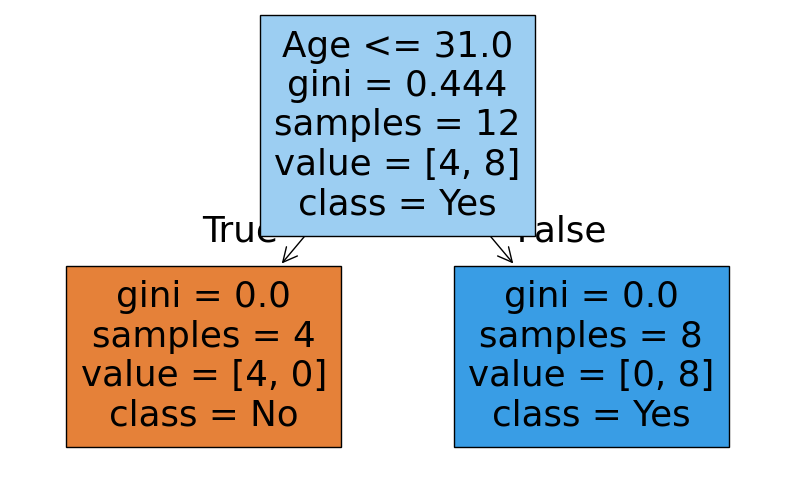

In [7]:
# visualize the decision tree

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()

In [8]:
#calculate the purity

yes = 8
no = 2

purity = max(yes, no) / (yes + no)

print("Purity:", purity)
print("Purity percentage:", purity * 100, "%")

Purity: 0.8
Purity percentage: 80.0 %


In [9]:
#calculate gini impurity

p_yes = 0.8
p_no = 0.2

gini = 1 - (p_yes**2 + p_no**2)

print("Gini Impurity =", gini)

Gini Impurity = 0.31999999999999984


In [10]:
# ENTROPY

import math

p_yes = 0.8
p_no = 0.2

entropy = -(p_yes * math.log2(p_yes) +
            p_no * math.log2(p_no))

print("Entropy =", entropy)

Entropy = 0.7219280948873623


In [11]:
new_people = pd.DataFrame({
    'Age': [24, 36, 44],
    'Income': [30, 55, 75]
})

predictions = model.predict(new_people)

result = new_people.copy()
result['Prediction'] = predictions
result['Prediction'] = result['Prediction'].map({
    0: 'No',
    1: 'Yes'
})
result

,Age,Income,Prediction
0,24,30,No
1,36,55,Yes
2,44,75,Yes


In [12]:
y_pred = model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0
